In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
df = pd.read_csv('hospital_readmissions.csv')

In [ ]:
# 1. Dataset Overview
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (25000, 17)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16

In [ ]:
# Set Seaborn style
sns.set_style('whitegrid')

Text(0, 0.5, 'Count')

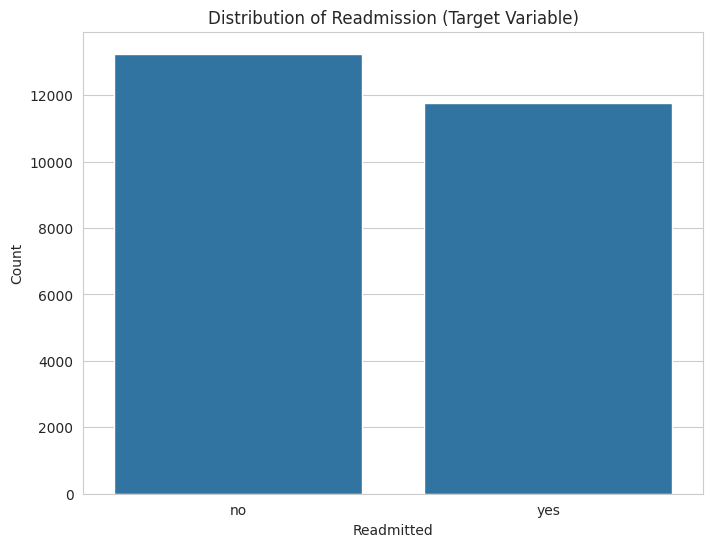

In [ ]:
# 2. Class Distribution (readmitted)
plt.figure(figsize=(8, 6))
sns.countplot(x='readmitted', data=df)
plt.title('Distribution of Readmission (Target Variable)')
plt.xlabel('Readmitted')
plt.ylabel('Count')


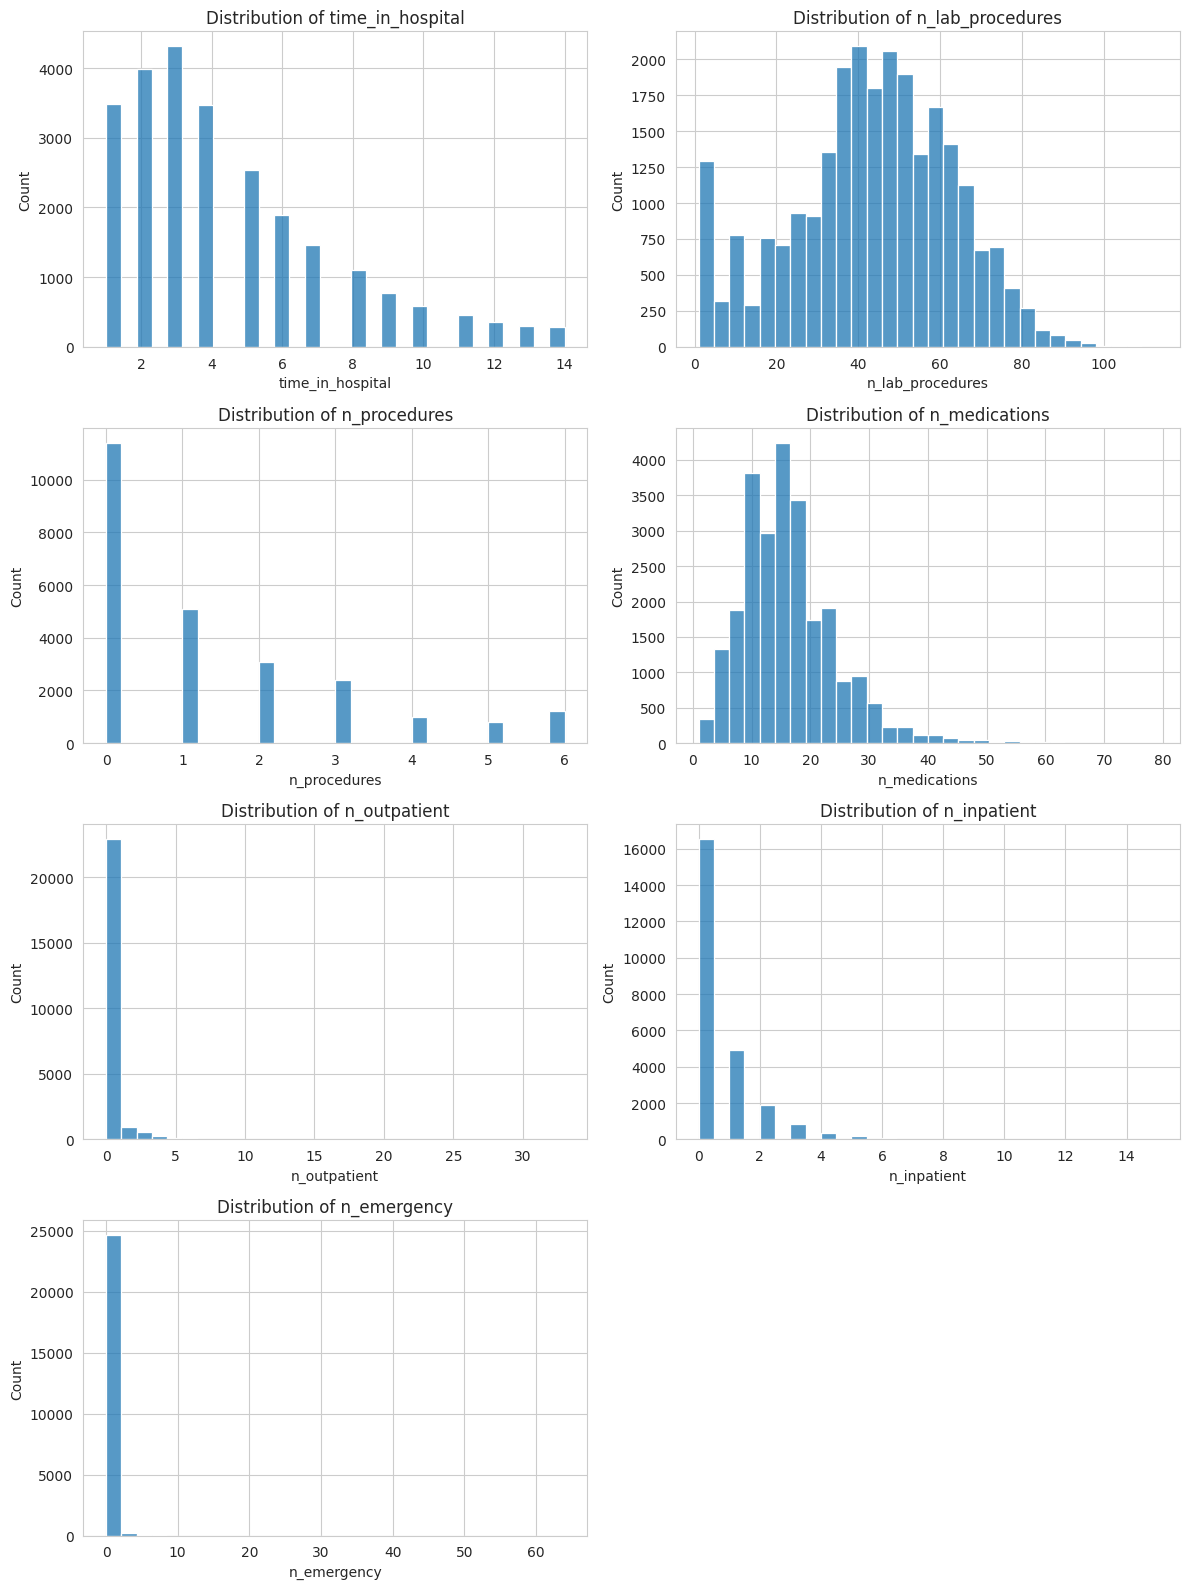

In [ ]:
# 3. Numerical Features Distribution
numerical_cols = ['time_in_hospital', 'n_lab_procedures', 'n_procedures',
                  'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # Convert data to float to ensure 30 bins are created correctly
    sns.histplot(df[col].astype(float), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove the extra subplot (8th subplot) since we have only 7 plots
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('numerical_distributions.png')

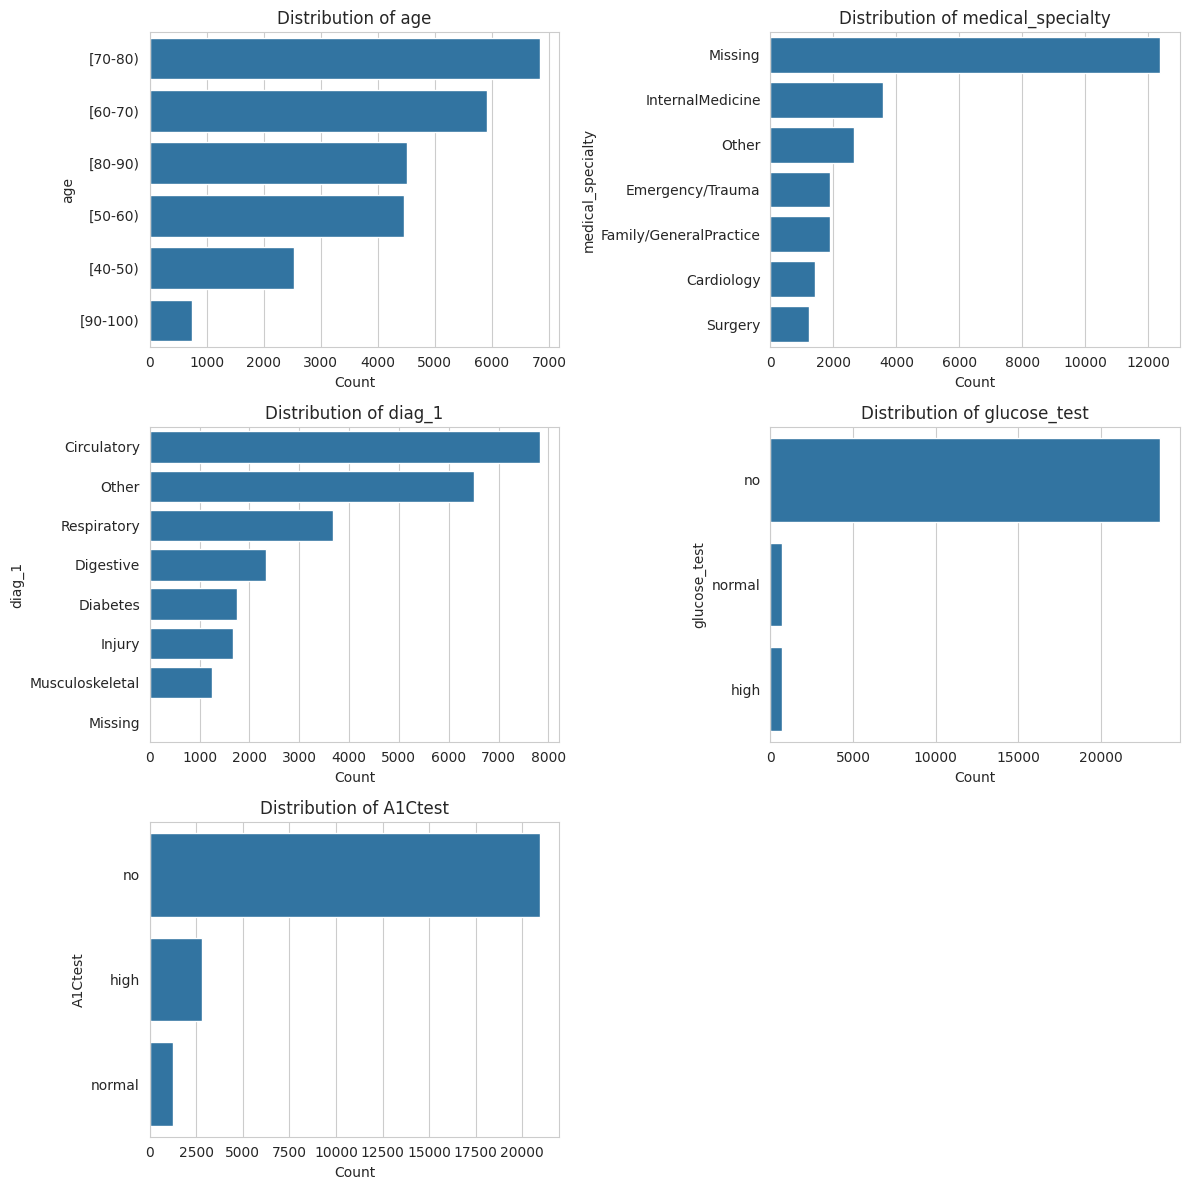

In [ ]:
# 4. Categorical Features Distribution (select key features)
categorical_cols = ['age', 'medical_specialty', 'diag_1', 'glucose_test', 'A1Ctest']
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(y=col, data=df, ax=axes[i], order=df[col].value_counts().index[:10])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)
axes[-1].axis('off')  # Hide extra subplot
plt.tight_layout()
plt.savefig('categorical_distributions.png')

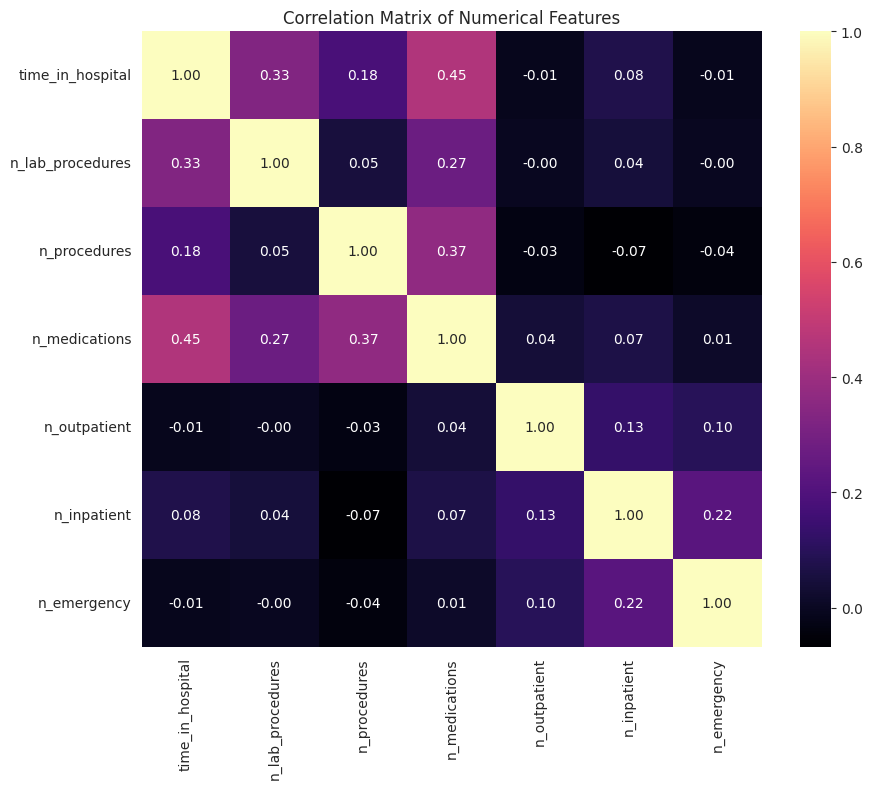

In [ ]:
# 5. Correlation Matrix (numerical features)
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='magma', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('correlation_matrix.png')

In [ ]:
# Compute the correlation matrix and round to two decimal places
corr_matrix = df[numerical_cols].corr().round(2)

# Print the table in a readable text format
print(corr_matrix.to_string())

                  time_in_hospital  n_lab_procedures  n_procedures  n_medications  n_outpatient  n_inpatient  n_emergency
time_in_hospital              1.00              0.33          0.18           0.45         -0.01         0.08        -0.01
n_lab_procedures              0.33              1.00          0.05           0.27         -0.00         0.04        -0.00
n_procedures                  0.18              0.05          1.00           0.37         -0.03        -0.07        -0.04
n_medications                 0.45              0.27          0.37           1.00          0.04         0.07         0.01
n_outpatient                 -0.01             -0.00         -0.03           0.04          1.00         0.13         0.10
n_inpatient                   0.08              0.04         -0.07           0.07          0.13         1.00         0.22
n_emergency                  -0.01             -0.00         -0.04           0.01          0.10         0.22         1.00


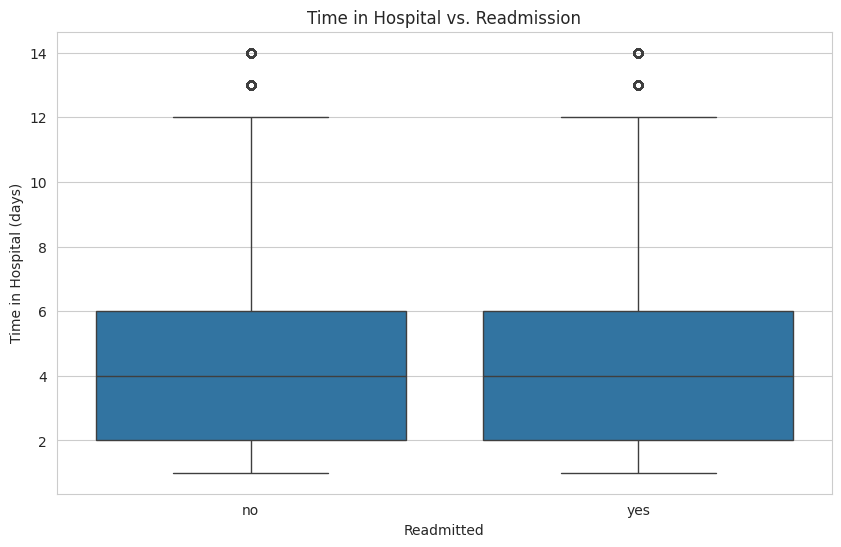

In [ ]:
# 6. Relationship between key features and readmission
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title('Time in Hospital vs. Readmission')
plt.xlabel('Readmitted')
plt.ylabel('Time in Hospital (days)')
plt.savefig('time_in_hospital_vs_readmitted.png')

In [ ]:
# !pip install joypy

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from joypy import joyplot
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
# Set plot style
sns.set_style("whitegrid")

In [ ]:
# 1. Parallel Coordinates Plot for Numerical Features
numerical_cols = ['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications',
                  'n_outpatient', 'n_inpatient', 'n_emergency']
temp_df = df[numerical_cols + ['readmitted']].copy()

# Encode 'readmitted' column to numerical values (yes=1, no=0)
le = LabelEncoder()
temp_df['readmitted_encoded'] = le.fit_transform(temp_df['readmitted'])

# Normalize numerical features for better visualization
temp_df[numerical_cols] = (temp_df[numerical_cols] - temp_df[numerical_cols].mean()) / temp_df[numerical_cols].std()

# Create Parallel Coordinates Plot
fig = px.parallel_coordinates(
    temp_df,
    color='readmitted_encoded',
    dimensions=numerical_cols,
    color_continuous_scale=px.colors.diverging.Tealrose,
    title='Parallel Coordinates Plot by Readmission Status',
    labels={'readmitted_encoded': 'Readmitted (0=No, 1=Yes)'}
)
fig.show()

<Figure size 1000x800 with 0 Axes>

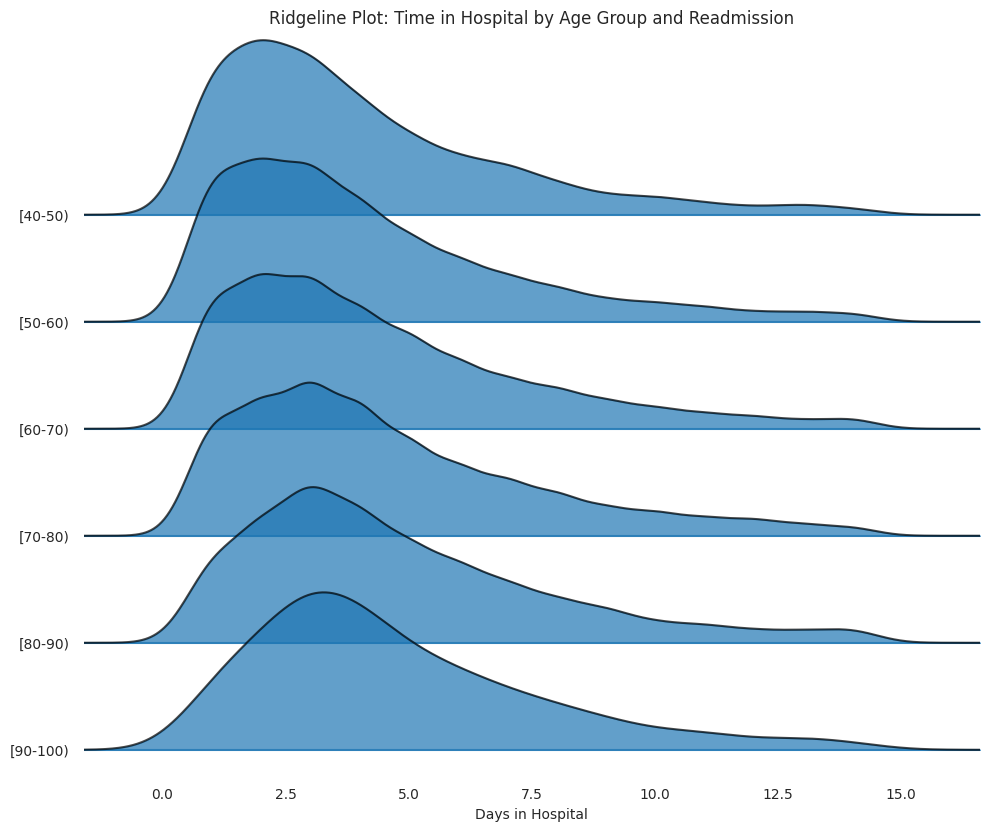

In [ ]:
# 2. Ridgeline Plot for Time in Hospital by Age Group and Readmission
plt.figure(figsize=(10, 8))
joyplot(data=df, by='age', column='time_in_hospital',
        overlap=1.5, alpha=0.7, figsize=(10, 8))
plt.title('Ridgeline Plot: Time in Hospital by Age Group and Readmission')
plt.xlabel('Days in Hospital')
plt.show()

In [ ]:
# 3. Sankey Diagram for Medical Specialty to Readmission
top_specialties = df['medical_specialty'].value_counts().head(5).index
sankey_df = df[df['medical_specialty'].isin(top_specialties)][['medical_specialty', 'readmitted']]
# Create node labels
nodes = list(top_specialties) + df['readmitted'].unique().tolist()
node_indices = {node: i for i, node in enumerate(nodes)}
# Create links
links = sankey_df.groupby(['medical_specialty', 'readmitted']).size().reset_index(name='count')
source = links['medical_specialty'].map(node_indices)
target = links['readmitted'].map(node_indices)
value = links['count']
# Plot Sankey
fig = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=nodes),
    link=dict(source=source, target=target, value=value))])
fig.update_layout(title_text="Sankey Diagram: Medical Specialty to Readmission", font_size=10)
fig.show()

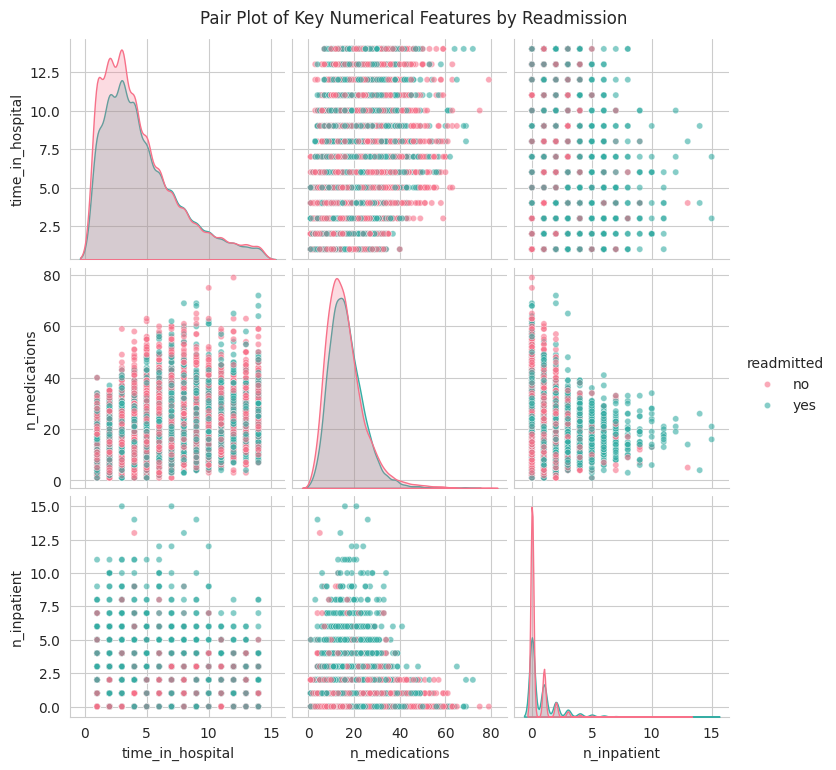

In [ ]:
# 4. Pair Plot with KDE and Scatter for Key Numerical Features
key_numerical = ['time_in_hospital', 'n_medications', 'n_inpatient', 'readmitted']
sns.pairplot(df[key_numerical], hue='readmitted', diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 20}, palette='husl')
plt.suptitle('Pair Plot of Key Numerical Features by Readmission', y=1.02)
plt.show()

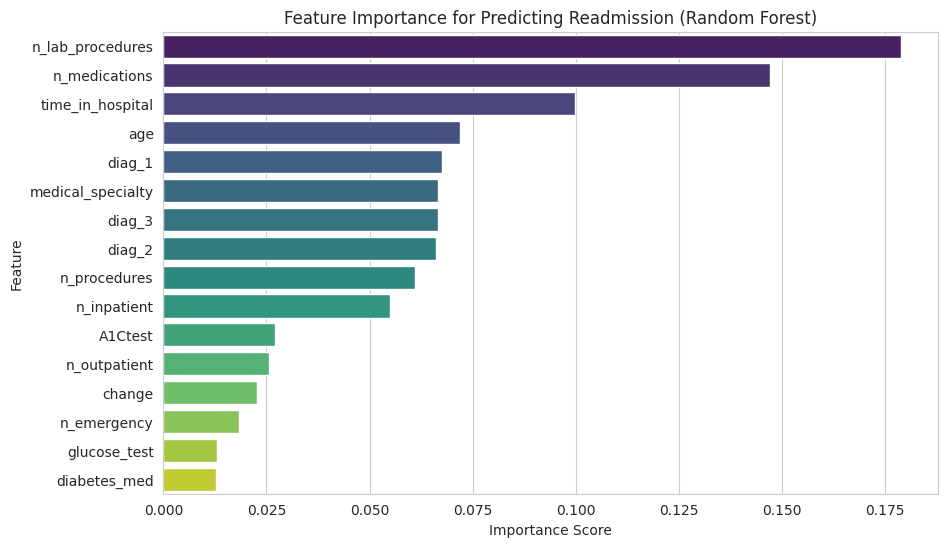

In [ ]:
# 5. Feature Importance Plot using Random Forest
# Prepare data for modeling
X = df.copy()
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])
y = X['readmitted']
X = X.drop('readmitted', axis=1)
# Train Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X, y)
# Plot feature importance
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis', hue = 'Feature')
plt.title('Feature Importance for Predicting Readmission (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [ ]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64


In [ ]:
# Drop any unexpected NaNs
df = df.dropna()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
# Encode categorical variables
categorical_cols = ['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
                    'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
# Standardize numerical features
numerical_cols = ['time_in_hospital', 'n_lab_procedures', 'n_procedures',
                  'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [ ]:
# Detect outliers using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return len(outliers)

# Print outliers for numerical columns
print("\nOutliers in Numerical Columns:")
for col in numerical_cols:
    print(f"{col}: {detect_outliers(df, col)} outliers")


Outliers in Numerical Columns:
time_in_hospital: 580 outliers
n_lab_procedures: 33 outliers
n_procedures: 1227 outliers
n_medications: 844 outliers
n_outpatient: 4141 outliers
n_inpatient: 1628 outliers
n_emergency: 2728 outliers


In [ ]:
# Save cleaned dataset
df.to_csv('cleaned_hospital_readmissions.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_hospital_readmissions.csv'")


Cleaned dataset saved as 'cleaned_hospital_readmissions.csv'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Load the dataset
df = pd.read_csv('cleaned_hospital_readmissions.csv')

In [ ]:
# Create new features
df['n_total_visits'] = df['n_outpatient'] + df['n_inpatient'] + df['n_emergency']
df['time_med_interaction'] = df['time_in_hospital'] * df['n_medications']
df['lab_proc_per_day'] = df['n_lab_procedures'] / (df['time_in_hospital'] + 1)  # Avoid division by zero

In [ ]:
# Feature importance using Random Forest
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [ ]:
# Select top 15 features
# Sort by Importance and select top 15 features
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
top_features = feature_importance.head(15)['Feature']
print("Top 15 Features:", top_features.tolist())

Top 15 Features: ['n_lab_procedures', 'n_medications', 'time_in_hospital', 'age', 'diag_1', 'medical_specialty', 'diag_3', 'diag_2', 'n_procedures', 'n_inpatient', 'A1Ctest', 'n_outpatient', 'change', 'n_emergency', 'glucose_test']


In [ ]:
X = df[top_features]
y = df['readmitted']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6016

Confusion Matrix:
 [[1812  846]
 [1146 1196]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.68      0.65      2658
           1       0.59      0.51      0.55      2342

    accuracy                           0.60      5000
   macro avg       0.60      0.60      0.60      5000
weighted avg       0.60      0.60      0.60      5000



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Define a smaller randomized parameter distribution
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'bootstrap': [True, False]
}

# Initialize the model
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=30, cv=5, n_jobs=-1, verbose=2,
                                   scoring='accuracy', random_state=42)

# Fit the model
random_search.fit(X_train, y_train)

# Best model
best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Accuracy:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 126}
Best Cross-Validation Accuracy: 0.6150499999999999


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]  # For ROC AUC if binary classification

print("Test Set Accuracy:", accuracy_score(y_test, y_pred))

Test Set Accuracy: 0.6184


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6184
Precision: 0.6174242424242424
Recall: 0.48719043552519214
F1 Score: 0.5446300715990453

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.73      0.67      2658
           1       0.62      0.49      0.54      2342

    accuracy                           0.62      5000
   macro avg       0.62      0.61      0.61      5000
weighted avg       0.62      0.62      0.61      5000



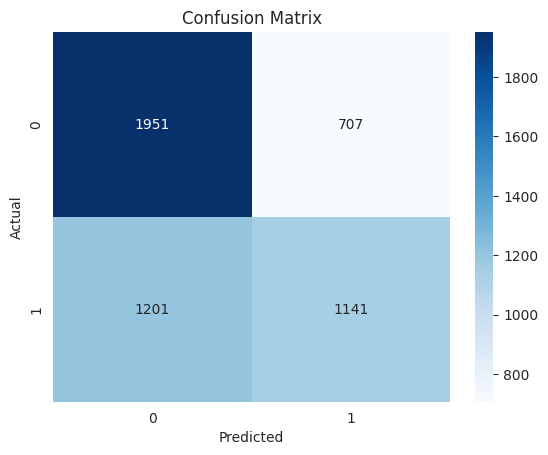

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

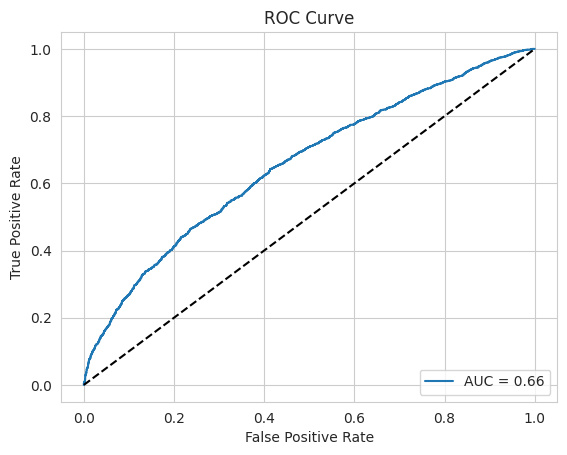

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[08:29:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.





XGBoost Model Evaluation Metrics:
Accuracy: 0.6062
Precision: 0.5908
Recall: 0.5179
F1-Score: 0.5520
ROC-AUC: 0.6346


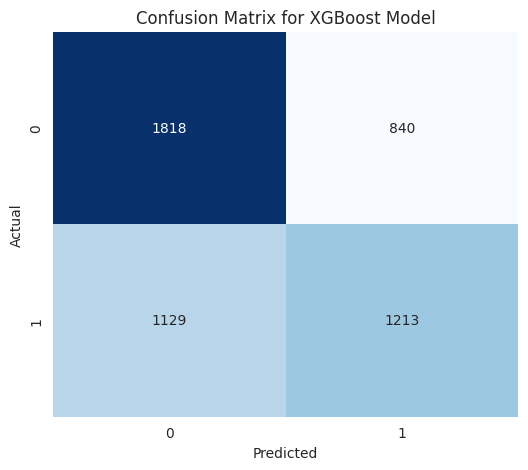

In [ ]:
# Initialize and train XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate model
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='binary'),
    'Recall': recall_score(y_test, y_pred, average='binary'),
    'F1-Score': f1_score(y_test, y_pred, average='binary'),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}

# Print evaluation metrics
print("\nXGBoost Model Evaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for XGBoost Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df[top_features]
y = df['readmitted']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Predict
y_pred_log = logreg.predict(X_test)

# Evaluation
print("🔹 Logistic Regression Results 🔹")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))


🔹 Logistic Regression Results 🔹
Accuracy: 0.609

Confusion Matrix:
 [[2118  540]
 [1415  927]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.80      0.68      2658
           1       0.63      0.40      0.49      2342

    accuracy                           0.61      5000
   macro avg       0.62      0.60      0.59      5000
weighted avg       0.61      0.61      0.59      5000



In [ ]:
from sklearn.neural_network import MLPClassifier

# Initialize and train the model
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)

# Predict
y_pred_mlp = mlp.predict(X_test)

# Evaluation
print("🔹 Neural Network (MLPClassifier) Results 🔹")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))

🔹 Neural Network (MLPClassifier) Results 🔹
Accuracy: 0.6094

Confusion Matrix:
 [[1957  701]
 [1252 1090]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.74      0.67      2658
           1       0.61      0.47      0.53      2342

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.60      5000
weighted avg       0.61      0.61      0.60      5000



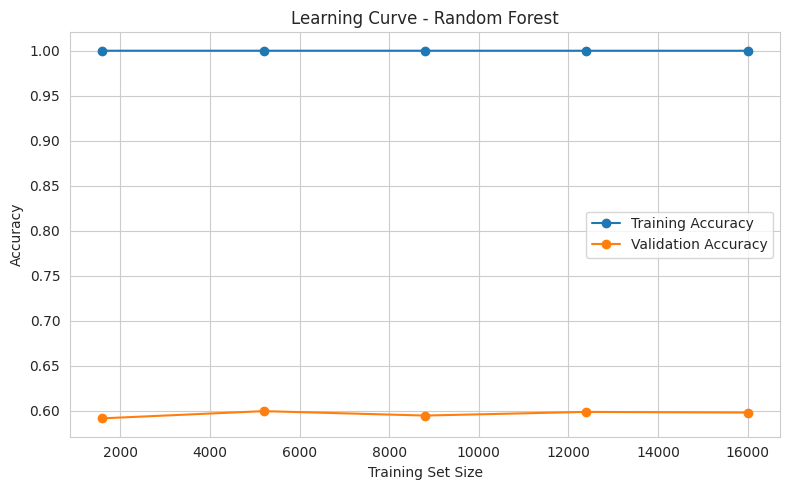

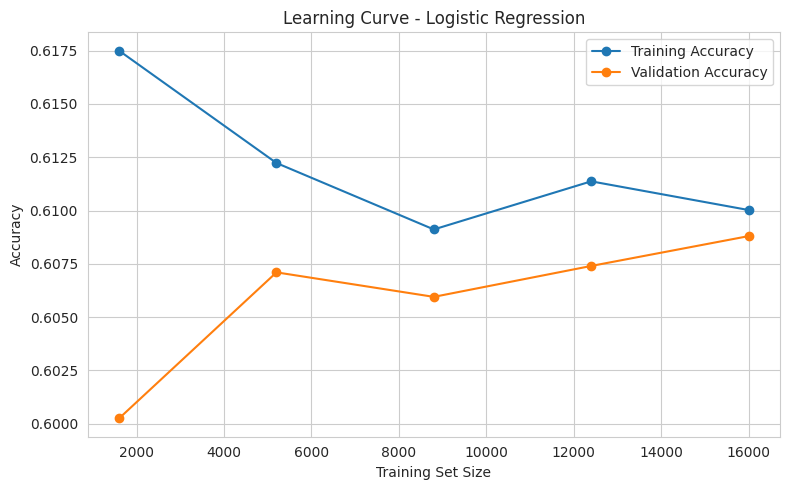

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

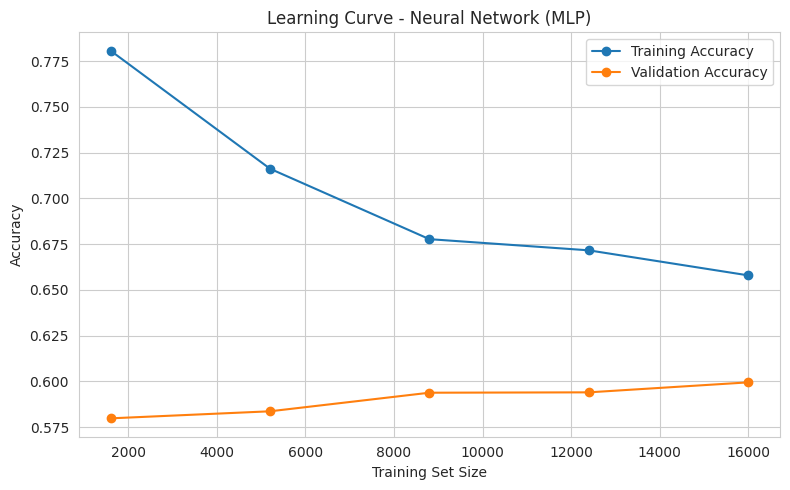

In [ ]:
import numpy as np
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv,
                                                             scoring='accuracy',
                                                             train_sizes=np.linspace(0.1, 1.0, 5),
                                                             random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores_mean, 'o-', label="Training Accuracy")
    plt.plot(train_sizes, test_scores_mean, 'o-', label="Validation Accuracy")
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call for each model
plot_learning_curve(rf, "Learning Curve - Random Forest", X_train, y_train)
plot_learning_curve(logreg, "Learning Curve - Logistic Regression", X_train, y_train)
plot_learning_curve(mlp, "Learning Curve - Neural Network (MLP)", X_train, y_train)


In [ ]:
# Align the columns of X_test with X_train
X_test = X_test[X_train.columns]

In [ ]:
print("Training Features:", X_train.columns)
print("Test Features:", X_test.columns)

Training Features: Index(['n_lab_procedures', 'n_medications', 'time_in_hospital', 'age',
       'diag_1', 'medical_specialty', 'diag_3', 'diag_2', 'n_procedures',
       'n_inpatient', 'A1Ctest', 'n_outpatient', 'change', 'n_emergency',
       'glucose_test'],
      dtype='object')
Test Features: Index(['n_lab_procedures', 'n_medications', 'time_in_hospital', 'age',
       'diag_1', 'medical_specialty', 'diag_3', 'diag_2', 'n_procedures',
       'n_inpatient', 'A1Ctest', 'n_outpatient', 'change', 'n_emergency',
       'glucose_test'],
      dtype='object')


In [ ]:
# Re-train the models
rf.fit(X_train, y_train)
logreg.fit(X_train, y_train)
mlp.fit(X_train, y_train)

MLPClassifier(max_iter=300, random_state=42)

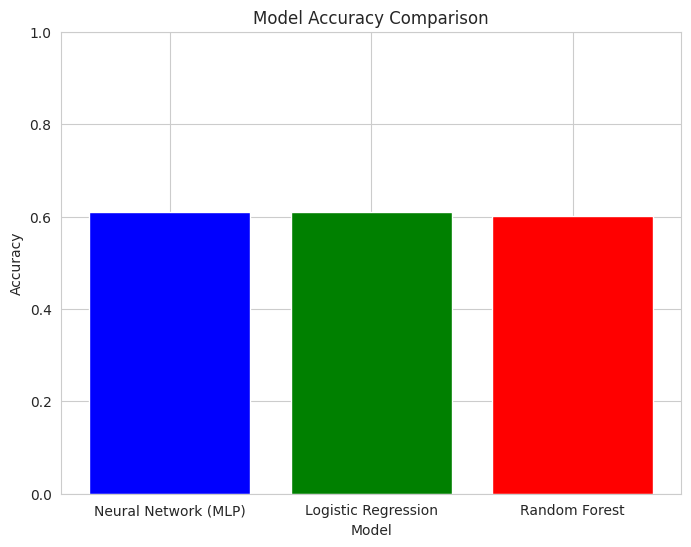

In [ ]:
# Collect accuracies for each model
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_log = accuracy_score(y_test, logreg.predict(X_test))
acc_mlp = accuracy_score(y_test, mlp.predict(X_test))

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'Neural Network (MLP)'],
    'Accuracy': [acc_rf, acc_log, acc_mlp]
})

# Sort by accuracy
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

# Plot the comparison graph
plt.figure(figsize=(8, 6))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['blue', 'green', 'red'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim([0, 1])  # Accuracy ranges from 0 to 1
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train_scaled, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    verbose=1)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5615 - loss: 0.6923 - val_accuracy: 0.6003 - val_loss: 0.6638
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5997 - loss: 0.6643 - val_accuracy: 0.6035 - val_loss: 0.6595
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6192 - loss: 0.6576 - val_accuracy: 0.6008 - val_loss: 0.6598
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6128 - loss: 0.6571 - val_accuracy: 0.5978 - val_loss: 0.6592
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6117 - loss: 0.6560 - val_accuracy: 0.6047 - val_loss: 0.6569
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6197 - loss: 0.6547 - val_accuracy: 0.6055 - val_loss: 0.6577
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6165 - loss: 0.6533 - val_accuracy: 0.5985 - val_loss: 0.6578
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6142 - loss: 0.6521 - val_accuracy: 0.

In [ ]:
y_pred_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6232
Precision: 0.6146146146146146
Recall: 0.5243381725021349
F1 Score: 0.5658986175115207

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.71      0.67      2658
           1       0.61      0.52      0.57      2342

    accuracy                           0.62      5000
   macro avg       0.62      0.62      0.62      5000
weighted avg       0.62      0.62      0.62      5000



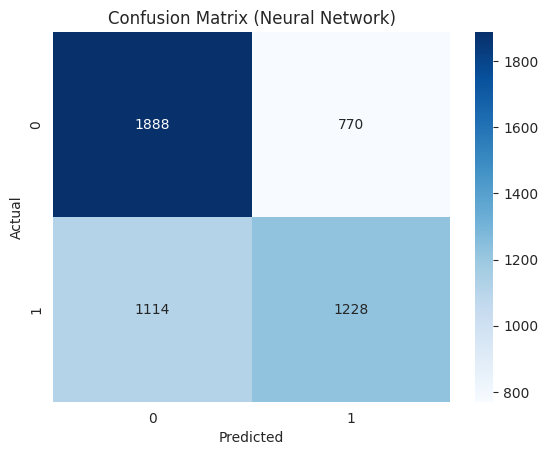

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Neural Network)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

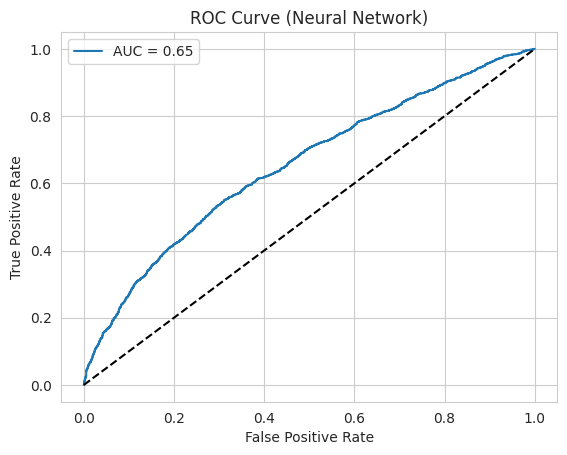

In [ ]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve (Neural Network)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

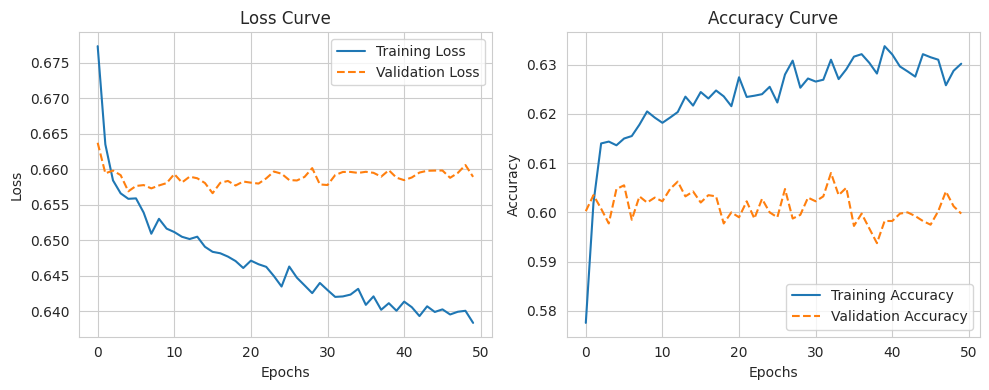

In [ ]:
plt.figure(figsize=(10, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()